In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from keras.preprocessing.text import Tokenizer
from keras_preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Dense, Embedding, LSTM, SpatialDropout1D
from sklearn.model_selection import train_test_split
from keras.utils.np_utils import to_categorical
from keras.callbacks import EarlyStopping
from keras.layers import Dropout
import re
# from nltk.corpus import stopwords
# from nltk import word_tokenize
# STOPWORDS = set(stopwords.words('english'))

In [4]:
df=pd.read_csv("bbc-text.csv")
df

,category,text,label
0,tech,tv future in the hands of viewers with home th...,3
1,business,worldcom boss left books alone former worldc...,0
2,sport,tigers wary of farrell gamble leicester say ...,2
3,sport,yeading face newcastle in fa cup premiership s...,2
4,entertainment,ocean s twelve raids box office ocean s twelve...,1
...,...,...,...
2220,business,cars pull down us retail figures us retail sal...,0
2221,politics,kilroy unveils immigration policy ex-chatshow ...,4
2222,entertainment,rem announce new glasgow concert us band rem h...,1
2223,politics,how political squabbles snowball it s become c...,4


In [5]:
df.describe()

,label
count,2225.000000
mean,1.923146
std,1.419586
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,4.000000


In [6]:
df.dtypes

category    object
text        object
label        int64
dtype: object

In [7]:
df['category'].nunique()

5

In [8]:
df['category'].value_counts()

sport            511
business         510
politics         417
tech             401
entertainment    386
Name: category, dtype: int64

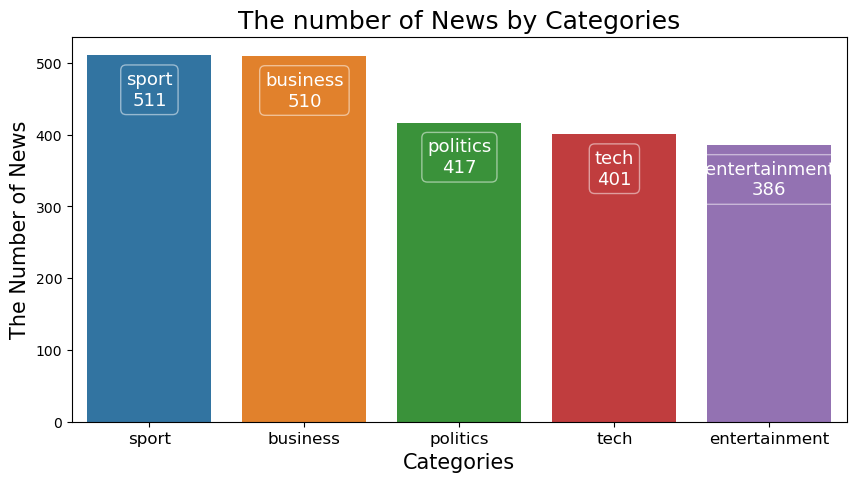

In [38]:
category_counts = df['category'].value_counts()
categories = category_counts.index

fig = plt.figure(figsize = (10,5))
ax = fig.add_subplot(111)
sns.barplot(x = category_counts.index , y = category_counts)
for a, p in enumerate(ax.patches):
    ax.annotate(f'{categories[a]}\n' + format(p.get_height(), '.0f'), xy = (p.get_x() + p.get_width() / 2.0, p.get_height()), xytext = (0,-25), size = 13, color = 'white' , ha = 'center', va = 'center', textcoords = 'offset points', bbox = dict(boxstyle = 'round', facecolor='none',edgecolor='white', alpha = 0.5) )
plt.xlabel('Categories', size = 15)
plt.ylabel('The Number of News', size= 15)
plt.xticks(size = 12)

plt.title("The number of News by Categories" , size = 18)
plt.show()

In [10]:
df['text'][10]

'berlin cheers for anti-nazi film a german movie about an anti-nazi resistance heroine has drawn loud applause at berlin film festival.  sophie scholl - the final days portrays the final days of the member of the white rose movement. scholl  21  was arrested and beheaded with her brother  hans  in 1943 for distributing leaflets condemning the  abhorrent tyranny  of adolf hitler. director marc rothemund said:  i have a feeling of responsibility to keep the legacy of the scholls going.   we must somehow keep their ideas alive   he added.  the film drew on transcripts of gestapo interrogations and scholl s trial preserved in the archive of communist east germany s secret police. their discovery was the inspiration behind the film for rothemund  who worked closely with surviving relatives  including one of scholl s sisters  to ensure historical accuracy on the film. scholl and other members of the white rose resistance group first started distributing anti-nazi leaflets in the summer of 19

In [11]:
df.isnull().sum()

category    0
text        0
label       0
dtype: int64

In [13]:
space = re.compile('[/(){}\[\]\|@,;]')
symbols= re.compile('[^0-9a-z #+_]')
STOPWORDS = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower() # lowercase text
    text = space.sub(' ', text) # replace REPLACE_BY_SPACE_RE symbols by space in text. substitute the matched string in REPLACE_BY_SPACE_RE with space.
    text = symbols.sub('', text) # remove symbols which are in BAD_SYMBOLS_RE from text. substitute the matched string in BAD_SYMBOLS_RE with nothing. 
    text = text.replace('x', '')
#    text = re.sub(r'\W+', '', text)
    text = ' '.join(word for word in text.split() if word not in STOPWORDS) # remove stopwors from text
    return text

In [14]:
df['text']=df['text'].apply(clean_text)

In [15]:
df['text'][10]

'berlin cheers antinazi film german movie antinazi resistance heroine drawn loud applause berlin film festival sophie scholl final days portrays final days member white rose movement scholl 21 arrested beheaded brother hans 1943 distributing leaflets condemning abhorrent tyranny adolf hitler director marc rothemund said feeling responsibility keep legacy scholls going must somehow keep ideas alive added film drew transcripts gestapo interrogations scholl trial preserved archive communist east germany secret police discovery inspiration behind film rothemund worked closely surviving relatives including one scholl sisters ensure historical accuracy film scholl members white rose resistance group first started distributing antinazi leaflets summer 1942 arrested dropped leaflets munich university calling day reckoning adolf hitler regime film focuses si days scholl arrest intense trial saw scholl initially deny charges ended defiant appearance one three german films vying top prize festiva

In [16]:
df['text'][50]

'lewsey puzzle disallowed try england josh lewsey claimed denied late try side si nations loss ireland wasps wing insisted grounded ball bundled line said referee jonathan kaplan made wrong decision positive touched ball line lewsey told bbc sport certainly turnover driven put ball ground whistle went let go ball lewsey added one irish players scooped back whistle surprise referee gave turnover far concerned incident mark cueto effort charlie hodgson crossfield kick led looked like good try two key elements game cueto also puzzled try disallowed kaplan think could offside without doubt behind ball said sale player move planned technique cuff rehearse time time say robbed decisions go go today went us tough international level'

In [17]:
g=[]

In [64]:
for i in df['text']:
    g.append(i)

In [28]:
len(g)

6675

In [29]:
len(g[4])

1207

In [ ]:
# for i in g:
#     print(len(i))

In [ ]:
# g

In [30]:
maxl = max([len(s) for s in g])
print ('Maximum sequence length in the list of sentences:', maxl)

Maximum sequence length in the list of sentences: 16201


In [12]:
tokenizer = Tokenizer(num_words=50000, filters='!"#$%&()*+,-./:;<=>?@[\]^_`{|}~', lower=True)
tokenizer.fit_on_texts(df['text'].values)
word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

Found 29726 unique tokens.


In [14]:
X = tokenizer.texts_to_sequences(df['text'].values)
X = pad_sequences(X, maxlen=3000)

In [15]:
X.shape

(2225, 3000)

In [16]:
Y = pd.get_dummies(df['category'],columns=df["category"]).values
Y

array([[0, 0, 0, 0, 1],
       [1, 0, 0, 0, 0],
       [0, 0, 0, 1, 0],
       ...,
       [0, 1, 0, 0, 0],
       [0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0]], dtype=uint8)

In [17]:
len(Y)

2225

In [18]:
Y[0]

array([0, 0, 0, 0, 1], dtype=uint8)

In [19]:
Y[1]

array([1, 0, 0, 0, 0], dtype=uint8)

In [20]:
Y[2]

array([0, 0, 0, 1, 0], dtype=uint8)

In [21]:
Y[2222]

array([0, 1, 0, 0, 0], dtype=uint8)

In [22]:
Y[2223]

array([0, 0, 1, 0, 0], dtype=uint8)

In [23]:
df.head(3)

,category,text,label
0,tech,tv future in the hands of viewers with home th...,3
1,business,worldcom boss left books alone former worldc...,0
2,sport,tigers wary of farrell gamble leicester say ...,2


In [24]:
df.tail(3)

,category,text,label
2222,entertainment,rem announce new glasgow concert us band rem h...,1
2223,politics,how political squabbles snowball it s become c...,4
2224,sport,souness delight at euro progress boss graeme s...,2


In [25]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.1, random_state = 42)
print(X_train.shape,Y_train.shape)
print(X_test.shape,Y_test.shape)

(2002, 3000) (2002, 5)
(223, 3000) (223, 5)


In [26]:
model=Sequential()
model.add(Embedding(50000,100,input_length=3000))
model.add(SpatialDropout1D(0.2))
model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(5, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [27]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 3000, 100)         5000000   
                                                                 
 spatial_dropout1d (SpatialD  (None, 3000, 100)        0         
 ropout1D)                                                       
                                                                 
 lstm (LSTM)                 (None, 100)               80400     
                                                                 
 dense (Dense)               (None, 5)                 505       
                                                                 
Total params: 5,080,905
Trainable params: 5,080,905
Non-trainable params: 0
_________________________________________________________________


In [28]:
history = model.fit(X_train, Y_train, epochs=7, batch_size=64,validation_split=0.1,callbacks=[EarlyStopping(monitor='val_loss', patience=3, min_delta=0.0001)])

Epoch 1/7
29/29 [==============================] - 318s 11s/step - loss: 1.5903 - accuracy: 0.2915 - val_loss: 1.5465 - val_accuracy: 0.3333
Epoch 2/7
29/29 [==============================] - 318s 11s/step - loss: 1.4327 - accuracy: 0.4314 - val_loss: 1.1508 - val_accuracy: 0.5970
Epoch 3/7
29/29 [==============================] - 318s 11s/step - loss: 0.9288 - accuracy: 0.6602 - val_loss: 0.8466 - val_accuracy: 0.6816
Epoch 4/7
29/29 [==============================] - 322s 11s/step - loss: 0.5730 - accuracy: 0.7446 - val_loss: 0.5422 - val_accuracy: 0.7463
Epoch 5/7
29/29 [==============================] - 342s 12s/step - loss: 0.6090 - accuracy: 0.8101 - val_loss: 0.7257 - val_accuracy: 0.7114
Epoch 6/7
29/29 [==============================] - 332s 11s/step - loss: 0.3556 - accuracy: 0.8984 - val_loss: 0.4271 - val_accuracy: 0.8657
Epoch 7/7
29/29 [==============================] - 325s 11s/step - loss: 0.2262 - accuracy: 0.9184 - val_loss: 0.3279 - val_accuracy: 0.8806


In [29]:
accr = model.evaluate(X_test,Y_test)
print('Test set\n  Loss: {:0.3f}\n  Accuracy: {:0.3f}'.format(accr[0],accr[1]))

7/7 [==============================] - 7s 987ms/step - loss: 0.5433 - accuracy: 0.8161
Test set
  Loss: 0.543
  Accuracy: 0.816


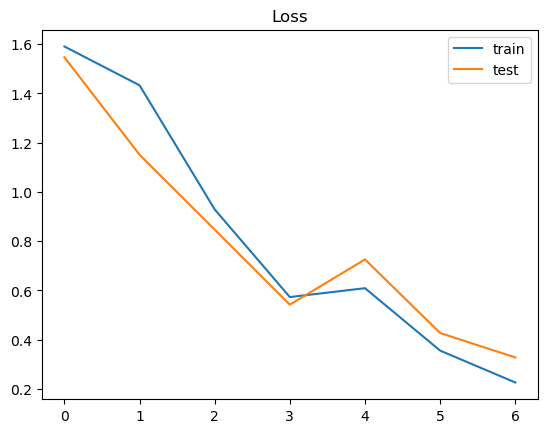

In [30]:
plt.title('Loss')
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show();

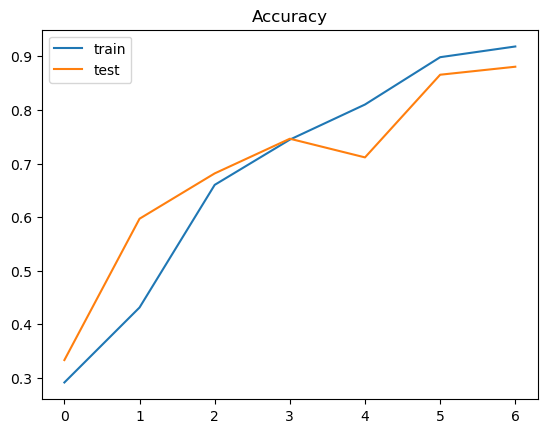

In [31]:
plt.title('Accuracy')
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.legend()
plt.show();

In [32]:
df['category'].value_counts()

sport            511
business         510
politics         417
tech             401
entertainment    386
Name: category, dtype: int64

In [33]:
new_complaint = ['Cricket Australia is set to begin the team’s pre-season later this month under a set of new training protocols devised for the safety of players amid the COVID-19 pandemic.']
seq = tokenizer.texts_to_sequences(new_complaint)
padded = pad_sequences(seq, maxlen=3000)
pred = model.predict(padded)
labels = ['Business','Entertainment','Politics','Sports','Tech']
print(pred, labels[np.argmax(pred)])

1/1 [==============================] - 1s 1s/step
[[0.01287743 0.00773403 0.00558745 0.9713722  0.002429  ]] Sports


In [34]:
new_complaint = ['Flipkart revealed the different items that Indians are looking for on the e-commerce site, as relaxing lockdown restrictions allow shopping to start again. Self-care and items to help work from home top the list, according to the e-commerce giant. ']
seq = tokenizer.texts_to_sequences(new_complaint)
padded = pad_sequences(seq, maxlen=3000)
pred = model.predict(padded)
labels = ['Business','Entertainment','Politics','Sports','Tech']
print(pred, labels[np.argmax(pred)])

1/1 [==============================] - 1s 584ms/step
[[0.06272326 0.17228554 0.30718428 0.01108498 0.44672188]] Tech


In [35]:
new_complaint =['Additionally, the microsite on Amazon.in highlights some of the key features of the Mi 10. It shows that the phone will come with a 108-megapixel primary camera that will have optical image stabilisation (OIS) and 8K video recording. The microsite also claims that the Mi 10 will carry the worlds fastest wireless charging and include Qualcomm Snapdragon 865 SoC. You can also expect a 3D curved TrueColor E3 AMOLED display with a Corning Gorilla Glass protection on top and stereo speakers.']
seq = tokenizer.texts_to_sequences(new_complaint)
padded = pad_sequences(seq, maxlen=3000)
pred = model.predict(padded)
labels = ['Business','Entertainment','Politics','Sports','Tech']
print(pred, labels[np.argmax(pred)])

1/1 [==============================] - 1s 599ms/step
[[0.34948608 0.06602525 0.14454235 0.03302743 0.4069188 ]] Tech


In [36]:
new_complaint = ['Having undergone a surgery for shoulder dislocation last month, young Australian pacer Jhye Richardson is hopeful of recovering from the recurring injury by the time cricketing action resumes. Cricket Australias chief medical officer Alex Kountouris sounded optimistic of the fast bowlers recovery process with respect to a comeback later this year.Its a lengthy surgery but it does give him an opportunity now that were not going to play until ... September, October, November or December ... hes obviously a chance with that, Kountouris told News Corp in an interaction.']
seq = tokenizer.texts_to_sequences(new_complaint)
padded = pad_sequences(seq, maxlen=3000)
pred = model.predict(padded)
labels = ['Business','Entertainment','Politics','Sports','Tech']
print(pred, labels[np.argmax(pred)])

1/1 [==============================] - 1s 600ms/step
[[0.29760343 0.00903737 0.02198225 0.640458   0.03091893]] Sports
